In [158]:
import pandas as pd
import matplotlib.pyplot as plt

In [159]:
df = pd.read_csv('./dataset/mock_time_series_property_data.csv')

In [160]:
df['date'] = pd.to_datetime(df['date'])

In [161]:
property_id = 'property_1'  
property_data = df[df['property_id'] == property_id]  

In [162]:
property_data.tail()

,property_id,date,price
115,property_1,2024-05-31,377800
116,property_1,2024-06-30,377300
117,property_1,2024-07-31,372000
118,property_1,2024-08-31,367500
119,property_1,2024-09-30,377000


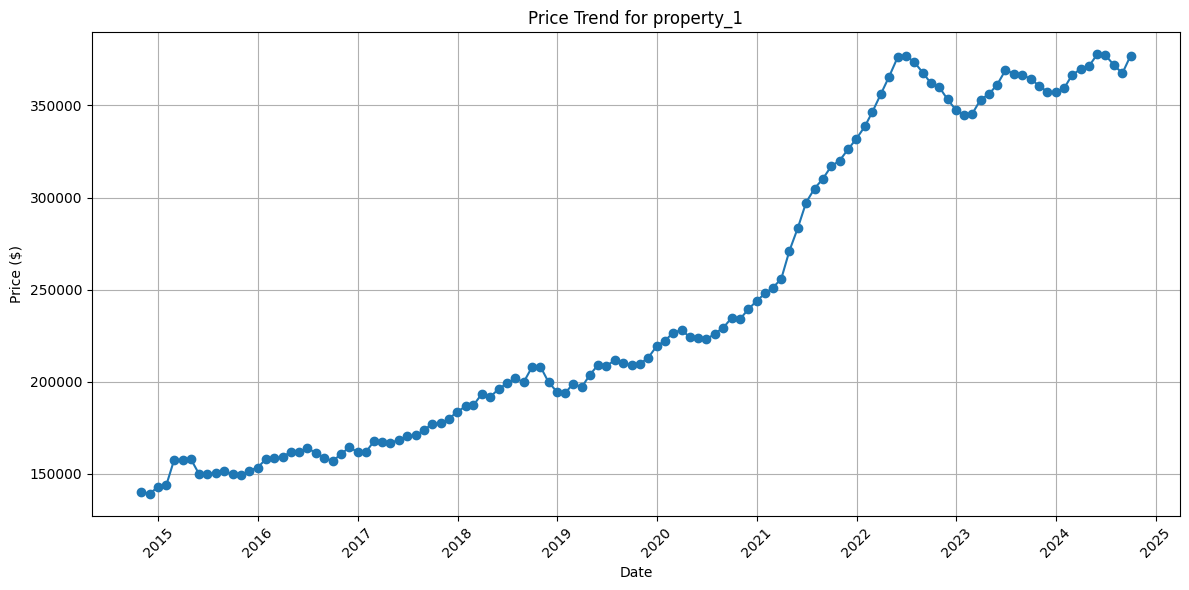

In [163]:
plt.figure(figsize=(12, 6))
plt.plot(property_data['date'], property_data['price'], marker='o')
plt.title(f'Price Trend for {property_id}')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid()
plt.xticks(rotation=45)  
plt.tight_layout()  
plt.show()

In [164]:
property_data = property_data.rename(columns={'date': 'ds', 'price': 'y'})
property_data = property_data.tail(69)
property_data

,property_id,ds,y
51,property_1,2019-01-31,194000
52,property_1,2019-02-28,198900
53,property_1,2019-03-31,196900
54,property_1,2019-04-30,203600
55,property_1,2019-05-31,209300
...,...,...,...
115,property_1,2024-05-31,377800
116,property_1,2024-06-30,377300
117,property_1,2024-07-31,372000
118,property_1,2024-08-31,367500


In [165]:
sales_df = pd.read_csv('./predicted_dataset/sale_predicted_stone_mountain.csv')
sales_df.rename(columns={'date': 'ds', 'Sales_Count': 'sales_count'}, inplace=True)
sales_df['ds'] = pd.to_datetime(sales_df['ds'])
old_sales_data = sales_df.head(69)
old_sales_data

,ds,sales_count
0,2019-01-31,13
1,2019-02-28,17
2,2019-03-31,29
3,2019-04-30,18
4,2019-05-31,25
...,...,...
64,2024-05-31,41
65,2024-06-30,34
66,2024-07-31,50
67,2024-08-31,29


In [166]:
merged_data = pd.merge(property_data, old_sales_data, on='ds', how='left')
merged_data

,property_id,ds,y,sales_count
0,property_1,2019-01-31,194000,13
1,property_1,2019-02-28,198900,17
2,property_1,2019-03-31,196900,29
3,property_1,2019-04-30,203600,18
4,property_1,2019-05-31,209300,25
...,...,...,...,...
64,property_1,2024-05-31,377800,41
65,property_1,2024-06-30,377300,34
66,property_1,2024-07-31,372000,50
67,property_1,2024-08-31,367500,29


In [167]:
from prophet import Prophet

# model = Prophet(seasonality_mode='additive',yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
# model.add_seasonality(name='summer_peak', period=12, fourier_order=5, prior_scale=10) 

# model = Prophet(yearly_seasonality=False, changepoint_prior_scale=0.1, seasonality_prior_scale=10.0 )
# model.add_seasonality(name='yearly', period=365.25, fourier_order=10)  
# model.add_seasonality(name='quarterly', period=91.25, fourier_order=5)

model = Prophet(yearly_seasonality=True, weekly_seasonality=True,daily_seasonality=False)

In [168]:
model.add_regressor('sales_count')
# model.add_regressor('market_change')

In [169]:
model.fit(merged_data)

16:39:24 - cmdstanpy - INFO - Chain [1] start processing


16:39:24 - cmdstanpy - INFO - Chain [1] done processing


In [170]:
future = model.make_future_dataframe(periods=11, freq='ME')
future['sales_count'] = sales_df['sales_count']

In [171]:
forecast = model.predict(future)

In [172]:
historical_forecast = forecast[forecast['ds'] < '2024-09-30']
future_forecast = forecast[forecast['ds'] >= '2024-09-30']

<Figure size 1200x600 with 0 Axes>

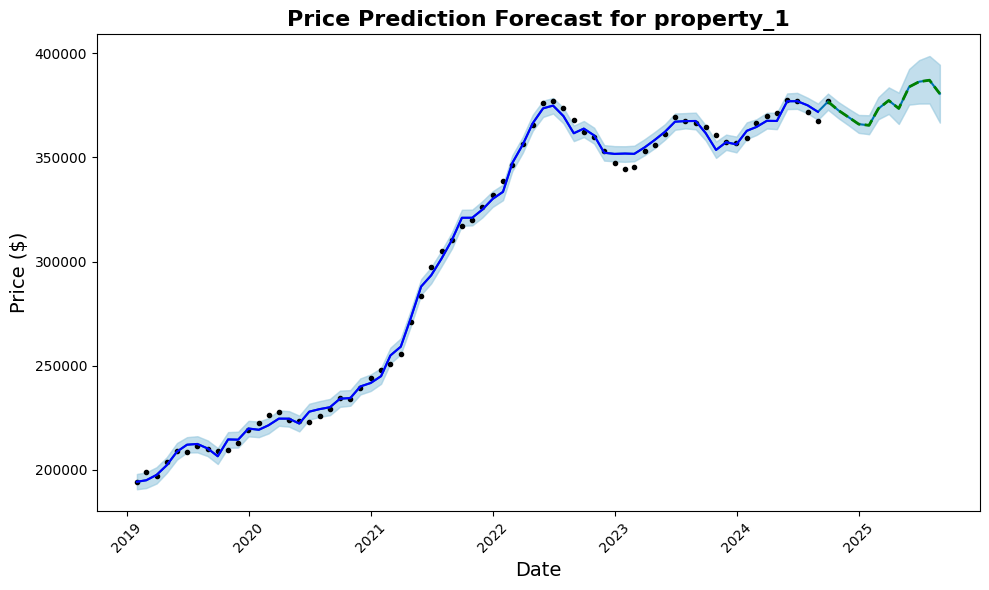

In [173]:
plt.figure(figsize=(12, 6))
model.plot(forecast)

plt.plot(historical_forecast['ds'], historical_forecast['yhat'], label='Historical Prices', color='blue')

plt.plot(future_forecast['ds'], future_forecast['yhat'], label='Predicted Prices', color='green', linestyle='--', linewidth=2)

plt.title(f'Price Prediction Forecast for {property_id}', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price ($)', fontsize=14)
plt.xticks(rotation=45)  
plt.grid()

plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='lightblue', alpha=0.3)

plt.tight_layout()  
plt.show()

In [174]:

predicted_prices = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)
predicted_prices.columns = ['Date', 'Predicted Price', 'Estimated Low Range', 'Estimated High Range']

print(predicted_prices.to_string(index=False))

      Date  Predicted Price  Estimated Low Range  Estimated High Range
2024-09-30    376801.888728        372889.824399         380622.936813
2024-10-31    372627.396091        368865.831529         376587.912757
2024-11-30    369388.988259        365474.133901         373458.653451
2024-12-31    365987.992706        361784.100238         370377.924550
2025-01-31    365416.782180        361152.640924         370250.780508
2025-02-28    373439.816885        368337.342651         378926.763361
2025-03-31    377336.298987        370881.859275         383616.425013
2025-04-30    373506.463529        366064.175837         381089.940164
2025-05-31    383852.464453        375345.042774         392450.809372
2025-06-30    386343.725271        375867.671634         396699.690130
2025-07-31    387067.628978        375879.533568         398690.963561
2025-08-31    380561.676079        366709.414763         394465.845912


In [175]:
predicted_prices.to_csv('./predicted_dataset/predicted_prices.csv', index=False)